# Multimodal PDF Document Parsing Workflow - Unstructured + PaddleOcr

This notebook demonstrates how to parse PDF documents and convert them to structured Markdown format, including extraction of multimodal content such as text, tables, and images.


## 1. Environment Setup

Before diving into structured PDF → Markdown parsing, we need to prepare the experimental environment.

### 1.1 Create Python Environment

It's recommended to use Python 3.9+ (3.10 or 3.11 preferred) to ensure compatibility.

```bash
# Create virtual environment using conda
conda create -n pdf_rag python=3.10 -y
conda activate pdf_rag

# Or use venv
python -m venv pdf_rag
source pdf_rag/bin/activate  # macOS/Linux
# pdf_rag\Scripts\activate  # Windows
```

### 1.2 Install Core Libraries

The core dependencies required for this project include:
- **PyMuPDF (fitz)**: For reading PDF files, extracting pages and images
- **matplotlib / pillow**: For visualization and image processing
- **unstructured**: Microsoft / LangChain recommended PDF document parsing library, supports structured chunking
- **paddleocr**: OCR engine for text region recognition

```bash
pip install "unstructured[all-docs]"   # Supports PDF / Word / PPT / HTML document parsing
pip install paddlenlp paddleocr        # OCR engine
pip install PyMuPDF pillow matplotlib  # PDF and image processing
pip install html2text                  # For HTML table to Markdown conversion
pip install langchain-unstructured     # LangChain integration
```


## 2. Load PDF and Extract Elements

Use `UnstructuredLoader` to parse PDF documents and extract structured content such as text, tables, and images.


In [4]:
# Import necessary libraries
from unstructured.partition.pdf import partition_pdf
from langchain_core.documents import Document
import os

# Specify PDF file path
file_path = "mckinsey-technology-trends-outlook-2025.pdf"

# Load document elements using partition_pdf directly
print("Parsing PDF document, this may take a few minutes...")

# Parse PDF with unstructured
elements = partition_pdf(
    filename=file_path,
    strategy="hi_res",              # High-resolution mode, supports complex documents
    infer_table_structure=True,     # Automatically parse table structure
    ocr_languages="chi_sim+eng",    # Support Chinese and English OCR
    ocr_engine="paddleocr"          # Specify PaddleOCR as OCR engine
)

# Convert elements to LangChain Documents, filtering out None or empty text
docs_local = []
skipped_count = 0

for element in elements:
    text = element.text if hasattr(element, 'text') else str(element)
    
    # Filter out elements with None or empty text
    if text is None or not text.strip():
        skipped_count += 1
        continue
    
    # Build metadata
    metadata = element.metadata.to_dict() if hasattr(element.metadata, 'to_dict') else {}
    metadata["category"] = element.category if hasattr(element, 'category') else "Unknown"
    
    # Create Document
    docs_local.append(Document(page_content=text, metadata=metadata))

print(f"✅ Parsing complete! Extracted {len(docs_local)} document elements")
if skipped_count > 0:
    print(f"ℹ️  Skipped {skipped_count} elements with no text content")


INFO: PDF text extraction failed, skip text extraction...
INFO: Reading PDF for file: mckinsey-technology-trends-outlook-2025.pdf ...


Parsing PDF document, this may take a few minutes...
✅ Parsing complete! Extracted 2123 document elements
ℹ️  Skipped 91 elements with no text content


### View Extracted Elements

Each `doc` contains:
- `page_content`: Text content
- `metadata`: Page number, coordinates, type, and other metadata


In [5]:
# View first few elements
for i, doc in enumerate(docs_local[:5]):
    print(f"\n{'='*60}")
    print(f"Element {i+1}:")
    print(f"Type: {doc.metadata.get('category', 'Unknown')}")
    print(f"Page: {doc.metadata.get('page_number', 'Unknown')}")
    print(f"Content: {doc.page_content[:200]}...")  # Only show first 200 characters



Element 1:
Type: Image
Page: 1
Content: McKinsey & Company...

Element 2:
Type: Title
Page: 1
Content: Technology Trends Outlook 2025. .«....

Element 3:
Type: Image
Page: 1
Content: July 2025 Fifth edition...

Element 4:
Type: NarrativeText
Page: 2
Content: Which frontier technologies matter most for companies in 2025? Our annual tech trends report highlights the latest technology breakthroughs, talent trends, use cases, and their potential impact on com...

Element 5:
Type: NarrativeText
Page: 2
Content: by Lareina Yee, Michael Chui, Roger Roberts, and Sven Smit...


## 3. Visualize PDF Element Extraction Results

To verify the actual element extraction results, we render PDF pages as images and draw bounding boxes for different elements (titles, tables, images, text, etc.).


In [6]:
import fitz
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from PIL import Image


def plot_pdf_with_boxes(pdf_page, segments):
    """
    Draw bounding boxes for recognized elements on PDF page
    
    Args:
        pdf_page: PyMuPDF Page object
        segments: List of elements containing coordinate information
    """
    # Render PDF page as image
    pix = pdf_page.get_pixmap()
    pil_image = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)

    # Create figure
    fig, ax = plt.subplots(1, figsize=(12, 14))
    ax.imshow(pil_image)
    
    # Define colors for different categories
    categories = set()
    category_to_color = {
        "Title": "orchid",
        "Image": "forestgreen",
        "Table": "tomato",
    }
    
    # Draw bounding boxes for each element
    for segment in segments:
        if "coordinates" not in segment:
            continue
            
        points = segment["coordinates"]["points"]
        layout_width = segment["coordinates"]["layout_width"]
        layout_height = segment["coordinates"]["layout_height"]
        
        # Scale coordinates to actual pixel coordinates
        scaled_points = [
            (x * pix.width / layout_width, y * pix.height / layout_height)
            for x, y in points
        ]
        
        box_color = category_to_color.get(segment["category"], "deepskyblue")
        categories.add(segment["category"])
        
        # Draw polygon box
        rect = patches.Polygon(
            scaled_points, linewidth=2, edgecolor=box_color, facecolor="none"
        )
        ax.add_patch(rect)

    # Create legend
    legend_handles = [patches.Patch(color="deepskyblue", label="Text")]
    for category in ["Title", "Image", "Table"]:
        if category in categories:
            legend_handles.append(
                patches.Patch(color=category_to_color[category], label=category)
            )
    
    ax.axis("off")
    ax.legend(handles=legend_handles, loc="upper right", fontsize=12)
    plt.tight_layout()
    plt.show()


def render_page(doc_list: list, page_number: int, print_text=True) -> None:
    """
    Render specified page and display recognized elements
    
    Args:
        doc_list: List of document elements
        page_number: Page number (starting from 1)
        print_text: Whether to print text content
    """
    pdf_page = fitz.open(file_path).load_page(page_number - 1)
    
    # Filter all elements for this page
    page_docs = [
        doc for doc in doc_list if doc.metadata.get("page_number") == page_number
    ]
    
    segments = [doc.metadata for doc in page_docs]
    
    print(f"\n📄 Page {page_number} - Total {len(page_docs)} elements\n")
    
    # Draw visualization
    plot_pdf_with_boxes(pdf_page, segments)
    
    # Print text content
    if print_text:
        print("\n" + "="*80)
        print("Text Content:")
        print("="*80)
        for i, doc in enumerate(page_docs, 1):
            category = doc.metadata.get('category', 'Unknown')
            print(f"\n[{i}] {category}:")
            print(f"{doc.page_content}\n")

print("✅ Visualization functions defined")


✅ Visualization functions defined


### View extraction results for page 1



📄 Page 10 - Total 25 elements



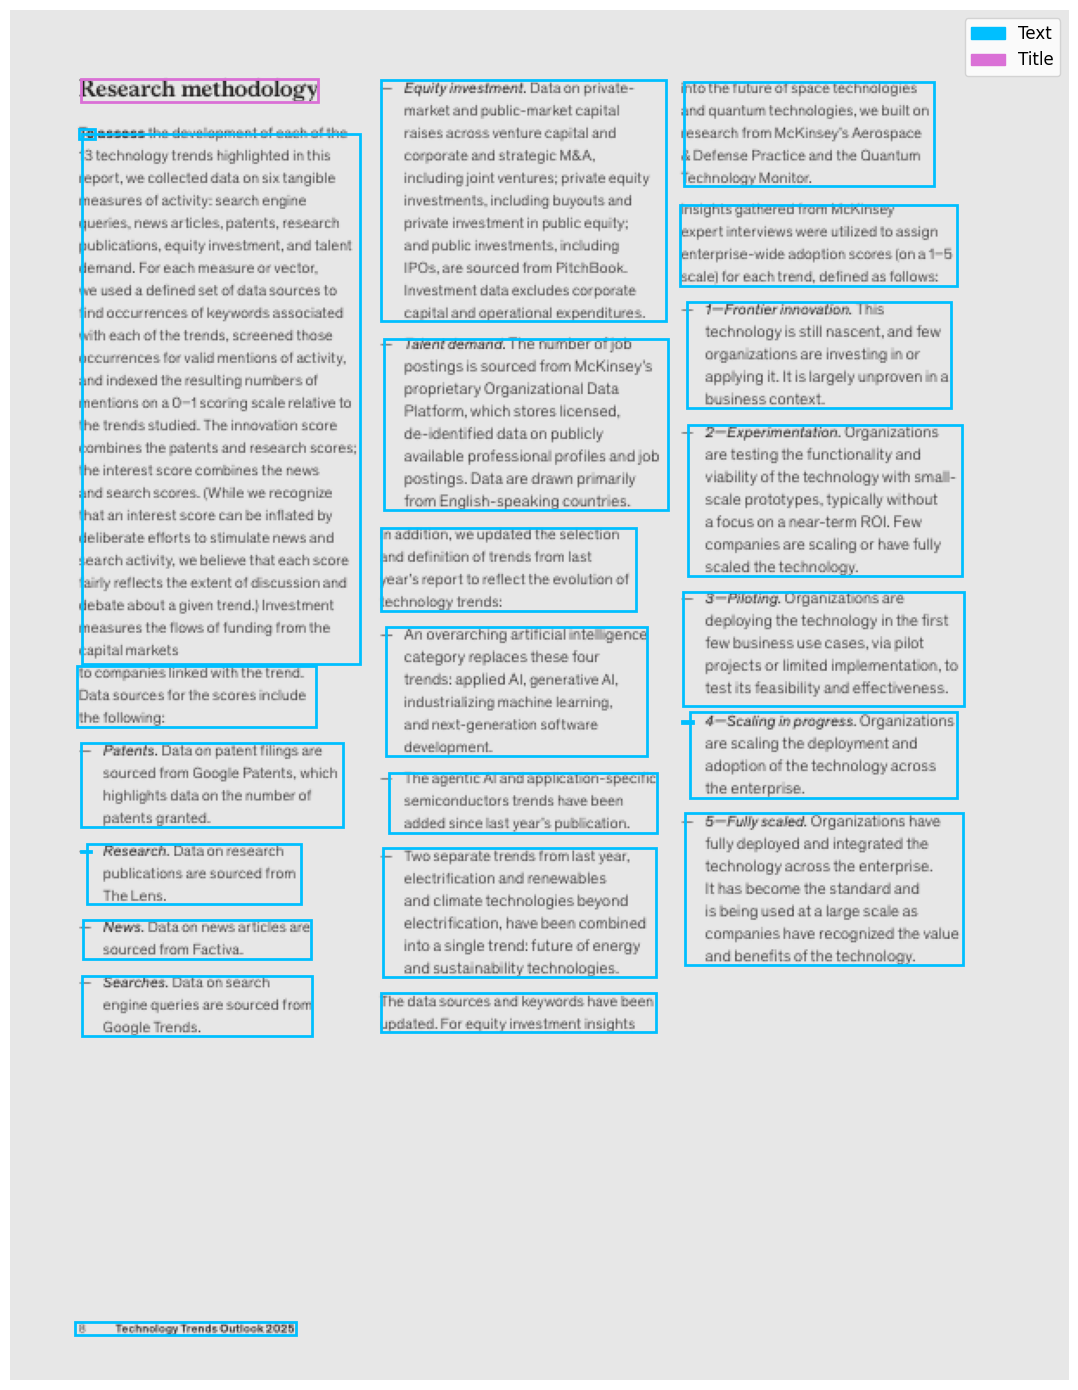


Text Content:

[1] Title:
Research methodology


[2] UncategorizedText:
To


[3] NarrativeText:
assess the development of each of the 13 technology trends highlighted in this report, we collected data on six tangible measures of activity: search engine queries, news articles, patents, research publications, equity investment, and talent demand. For each measure or vector, we used a defined set of data sources to find occurrences of keywords associated with each of the trends, screened those occurrences for valid mentions of activity, and indexed the resulting numbers of mentions ona O-1 scoring scale relative to e trends studied. The innovation score combines the patents and research scores; e interest score combines the news and search scores. (While we recognize at an interest score can be inflated by deliberate efforts to stimulate news and search activity, we believe that each score airly reflects the extent of discussion and debate about a given trend.) Investment measures the fl

In [7]:
render_page(docs_local, 10)


### View more pages

You can modify the page number to view extraction results for different pages



📄 Page 12 - Total 1 elements



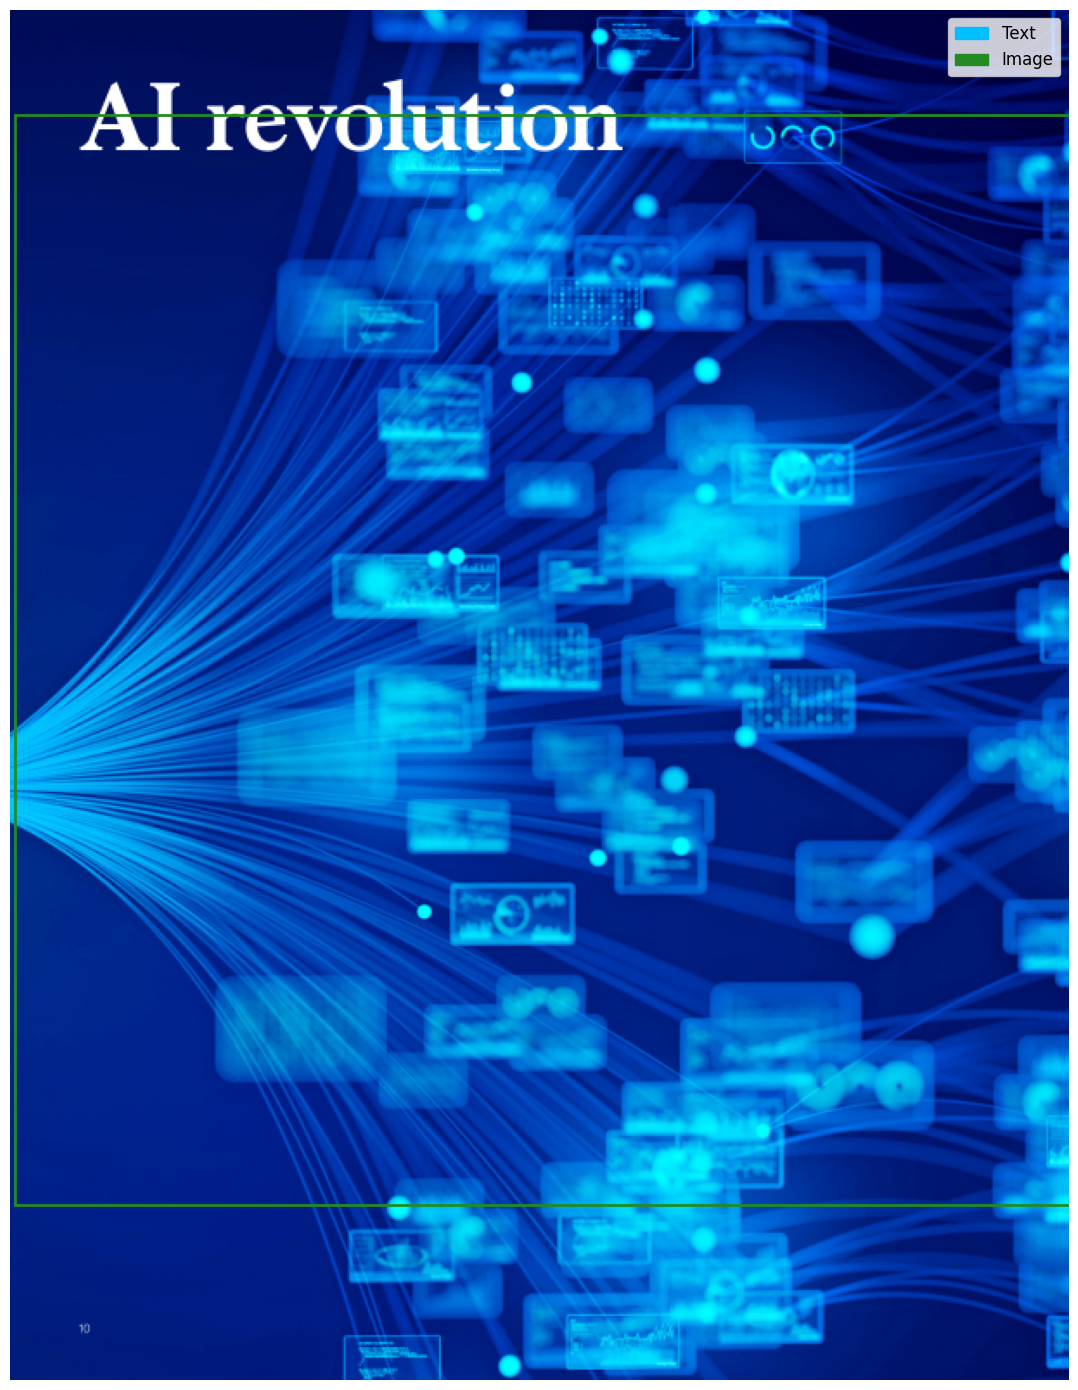


Text Content:

[1] Image:
AI revolution



In [8]:
# View page 2
render_page(docs_local, 12)



📄 Page 20 - Total 12 elements



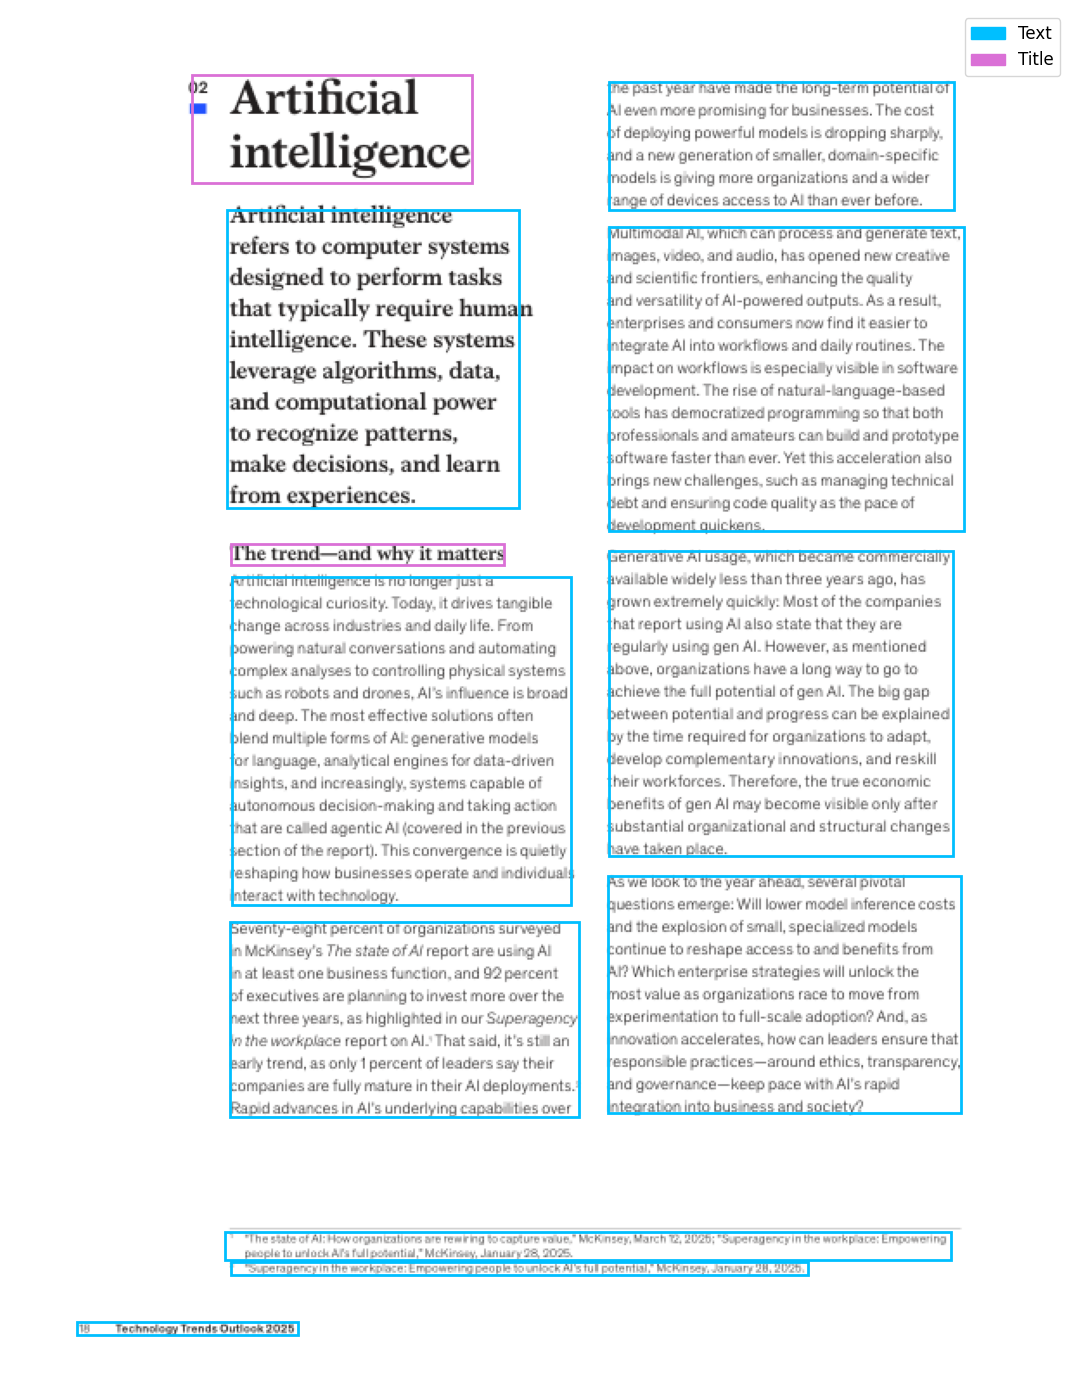


Text Content:

[1] Title:
= Artificial intelligence


[2] NarrativeText:
the past year have made the long-term potential of Al even more promising for businesses. The cost of deploying powerful models is dropping sharply, and anew generation of smaller, domain-specific models is giving more organizations and a wider range of devices access to Al than ever before.


[3] NarrativeText:
Artificial intelligence refers to computer systems designed to perform tasks that typically require human intelligence. These systems leverage algorithms, data, and computational power to recognize patterns, make decisions, and learn from experiences.


[4] NarrativeText:
Multimodal Al, which can process and generate text, images, video, and audio, has opened new creative and scientific frontiers, enhancing the quality and versatility of Al-powered outputs. As a result, enterprises and consumers now find it easier to integrate Al into workflows and daily routines. The impact on workflows is especially vis

In [9]:
# View page 3 (if it contains tables)
render_page(docs_local, 20)


## 4. Convert PDF to Markdown Document

Now we'll convert the extracted content into a structured Markdown document, including:
- Title hierarchy
- Tables (HTML → Markdown)
- Image references
- Text paragraphs


In [10]:
import os
import fitz
from unstructured.partition.pdf import partition_pdf

# Set output paths
pdf_path = file_path
output_dir = "pdf_images_demo"
os.makedirs(output_dir, exist_ok=True)

print("Performing complete PDF parsing (including image extraction)...")
print("This may take a few minutes, please be patient...\n")


Performing complete PDF parsing (including image extraction)...
This may take a few minutes, please be patient...



### Step 1: Extract text and structured content


In [11]:
# Use partition_pdf for complete parsing
elements = partition_pdf(
    filename=pdf_path,
    infer_table_structure=True,   # Enable table structure detection
    strategy="hi_res",            # High-resolution OCR, suitable for complex tables
    ocr_languages="chi_sim+eng",  # Chinese and English mixed recognition
    ocr_engine="paddleocr"        # Specify PaddleOCR engine
)

print(f"✅ Extraction complete! Recognized {len(elements)} elements")


INFO: PDF text extraction failed, skip text extraction...
INFO: Reading PDF for file: mckinsey-technology-trends-outlook-2025.pdf ...


✅ Extraction complete! Recognized 2214 elements


### Step 2: Extract and save images


In [12]:
doc = fitz.open(pdf_path)
image_map = {}  # Map page_num -> list of image paths

total_images = 0
for page_num, page in enumerate(doc, start=1):
    image_map[page_num] = []
    for img_index, img in enumerate(page.get_images(full=True), start=1):
        try:
            xref = img[0]
            pix = fitz.Pixmap(doc, xref)
            img_path = os.path.join(output_dir, f"page{page_num}_img{img_index}.png")
            
            # Convert to RGB if necessary (handles CMYK and other unsupported colorspaces)
            if pix.colorspace and pix.colorspace.name not in ["DeviceRGB", "DeviceGray"]:
                pix = fitz.Pixmap(fitz.csRGB, pix)
            
            # Handle alpha channel for grayscale/RGB images
            if pix.alpha:
                # Keep alpha channel for transparency
                pix.save(img_path)
            else:
                pix.save(img_path)
            
            # Explicitly delete pixmap to free memory
            del pix
            
            image_map[page_num].append(img_path)
            total_images += 1
            
        except Exception as e:
            print(f"Warning: Could not extract image {img_index} from page {page_num}: {str(e)}")
            continue

print(f"✅ Image extraction complete! Saved {total_images} images to {output_dir}/ directory")


✅ Image extraction complete! Saved 41 images to pdf_images_demo/ directory


### Step 3: Convert to Markdown format


In [13]:
md_lines = []
inserted_images = set()  # Track inserted images to avoid duplicates

for el in elements:
    cat = el.category
    text = el.text
    page_num = el.metadata.page_number

    # Handle titles
    if cat == "Title" and text.strip().startswith("- "):
        md_lines.append(text + "\n")
    elif cat == "Title":
        md_lines.append(f"# {text}\n")
    elif cat in ["Header", "Subheader"]:
        md_lines.append(f"## {text}\n")
    
    # Handle tables
    elif cat == "Table":
        if hasattr(el.metadata, "text_as_html") and el.metadata.text_as_html:
            from html2text import html2text
            md_lines.append(html2text(el.metadata.text_as_html) + "\n")
        else:
            md_lines.append(el.text + "\n")
    
    # Handle images
    elif cat == "Image":
        # Avoid duplicates: only insert corresponding image files
        for img_path in image_map.get(page_num, []):
            if img_path not in inserted_images:
                md_lines.append(f"![Image]({img_path})\n")
                inserted_images.add(img_path)
    
    # Handle other text
    else:
        md_lines.append(text + "\n")

print(f"✅ Markdown content assembly complete! Total {len(md_lines)} lines")


✅ Markdown content assembly complete! Total 2100 lines


### Step 4: Write to Markdown file


In [14]:
# Generate output filename (based on original PDF filename)
base_name = os.path.splitext(os.path.basename(pdf_path))[0]
output_md = f"{base_name}_output.md"

with open(output_md, "w", encoding="utf-8") as f:
    f.write("\n".join(md_lines))

print(f"\n🎉 Conversion complete!")
print(f"📝 Markdown file: {output_md}")
print(f"🖼️  Image folder: {output_dir}/")
print(f"📊 Statistics:")
print(f"   - Total elements: {len(elements)}")
print(f"   - Total images: {total_images}")
print(f"   - Markdown lines: {len(md_lines)}")



🎉 Conversion complete!
📝 Markdown file: mckinsey-technology-trends-outlook-2025_output.md
🖼️  Image folder: pdf_images_demo/
📊 Statistics:
   - Total elements: 2214
   - Total images: 41
   - Markdown lines: 2100


### Preview generated Markdown content


In [ ]:
# Read and preview generated Markdown file (first 50 lines)
with open(output_md, "r", encoding="utf-8") as f:
    lines = f.readlines()
    preview_lines = lines[:50]
    
print("📖 Markdown file preview (first 50 lines):")
print("="*80)
print("".join(preview_lines))
if len(lines) > 50:
    print(f"\n... {len(lines) - 50} more lines ...")


📖 Markdown file preview (first 50 lines):
![Image](pdf_images_demo/page1_img1.png)

![Image](pdf_images_demo/page1_img2.png)

# Technology Trends Outlook 2025. .«.

Which frontier technologies matter most for companies in 2025? Our annual tech trends report highlights the latest technology breakthroughs, talent trends, use cases, and their potential impact on companies across sectors.

by Lareina Yee, Michael Chui, Roger Roberts, and Sven Smit

# Contents

# Introduction

2

![Image](pdf_images_demo/page3_img1.png)

![Image](pdf_images_demo/page3_img2.png)

![Image](pdf_images_demo/page3_img3.png)

# Al revolution

10

01 Agentic Al

1

02 Artificial intelligence

18

# Compute and connectivity frontiers 26

03 Application-specific semiconductors 27

04 Advanced connectivity

34

05 Cloud and edge computing

Al

06 Immersive-reality technologies 48

07 Digital trust and cybersecurity 55



... 4149 more lines ...


## 5. Statistical Analysis

Analyze the distribution of extracted element types


📊 Element Type Statistics:
NarrativeText       :  624 (28.2%)
ListItem            :  606 (27.4%)
UncategorizedText   :  372 (16.8%)
Title               :  274 (12.4%)
Image               :  154 (7.0%)
Footer              :  106 (4.8%)
FigureCaption       :   76 (3.4%)
Header              :    2 (0.1%)


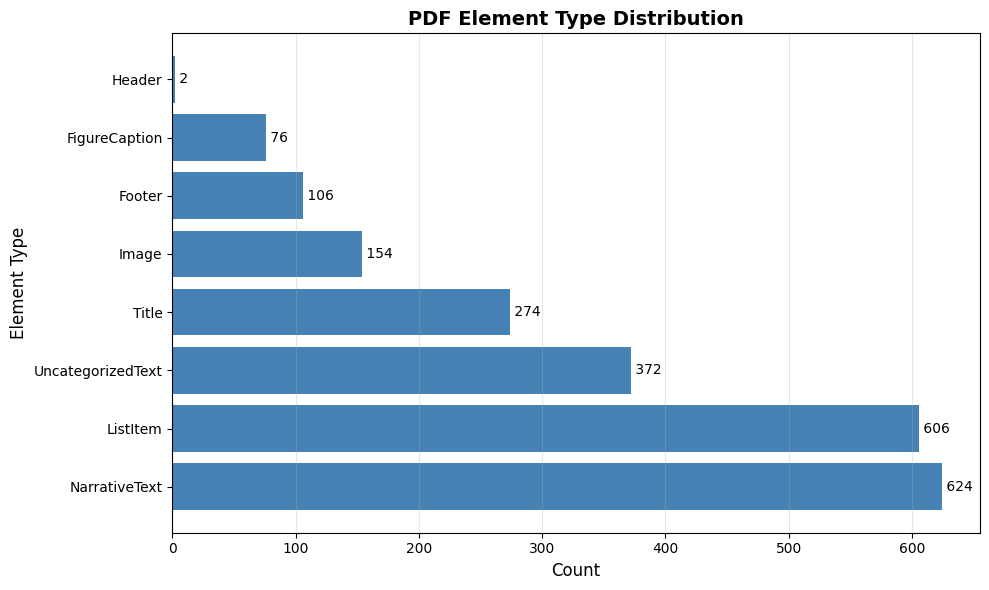

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# Count element types
categories = [el.category for el in elements]
category_counts = Counter(categories)

# Print statistics
print("📊 Element Type Statistics:")
print("="*50)
for cat, count in category_counts.most_common():
    print(f"{cat:20s}: {count:4d} ({count/len(elements)*100:.1f}%)")

# Draw bar chart
fig, ax = plt.subplots(figsize=(10, 6))
cats = [cat for cat, _ in category_counts.most_common()]
counts = [count for _, count in category_counts.most_common()]

ax.barh(cats, counts, color='steelblue')
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Element Type', fontsize=12)
ax.set_title('PDF Element Type Distribution', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Display values on bar chart
for i, (cat, count) in enumerate(zip(cats, counts)):
    ax.text(count, i, f' {count}', va='center')

plt.tight_layout()
plt.show()


## 6. Summary

### Application Scenarios

- 📚 **Document Knowledge Base Construction**: Convert PDFs to searchable Markdown format
- 🤖 **RAG Systems**: Provide structured documents for Retrieval-Augmented Generation
- 📊 **Academic Paper Analysis**: Extract tables, charts, and text from research papers
- 📖 **E-book Processing**: Convert PDF e-books to readable text format

### Future Optimization Directions

- Improve table recognition accuracy
- Optimize image caption association
- Support more document formats (Word, PPT, etc.)
- Integrate vector databases for semantic search
